In [77]:
import sys
import importlib
def reload_modules(*modules):
    for module in modules:
        if module.__name__ in sys.modules:
            importlib.reload(module)
        else:
            print(f"Module {module.__name__} is not currently imported.")

import numpy as np
import copy
from PIL import Image
import cv2
import open3d as o3d
import importlib
import imutils
import matplotlib.pyplot as plt
from magpie_perception import pcd
from magpie_perception import utils
from magpie_perception.utils import label_wrist_image, find_object
from magpie_control import realsense_wrapper as real
from magpie_control import ur5
from magpie_control import gripper
reload_modules(pcd, utils, real, ur5, gripper)

# with help from: https://github.com/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb
import os
from google import genai
import openai
from dotenv import load_dotenv
import instructor
from magpie_prompts.prompts import sf_force_thinker
from magpie_prompts import conversation
from magpie_prompts.conversation import openai_encode_image, create_image_message, send_message
from magpie_prompts.prompts import sf_grasp_selection
reload_modules(sf_force_thinker, sf_grasp_selection, conversation)

load_dotenv()
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
OPENAI_API_KEY = os.getenv('CORRELL_API_KEY')
GEMINI_MODEL_ID = "gemini-2.0-flash" # @param ["gemini-1.5-flash-latest","gemini-2.0-flash-lite","gemini-2.0-flash","gemini-2.5-pro-exp-03-25"] {"allow-input":true}
# OPENAI_MODEL_ID = "gpt-4o-mini"
OPENAI_MODEL_ID = "gpt-4o"

gemini_client = genai.Client(api_key=GEMINI_API_KEY)
openai_client = openai.OpenAI(api_key=OPENAI_API_KEY)
force_thinker = sf_force_thinker.PromptForceThinker()

In [2]:
from magpie_perception.label import Label
from magpie_perception.label_owlvit import LabelOWLViT
from magpie_perception.label_owlv2  import LabelOWLv2
from magpie_perception.label_dino   import LabelDINO
from magpie_perception.mask_sam2    import MaskSAM2

label_models = {'owl-vit': LabelOWLViT(),
                'owl-v2':  LabelOWLv2(),
                'dino':    LabelDINO(),}
mask_models = {'mask': MaskSAM2(),
               'box-dbscan': None}
label_model = label_models['owl-vit']
label_model = label_models['owl-v2']
label_model.init()

/home/will/miniconda3/envs/octo/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-04-07 12:09:06.854616: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-07 12:09:06.854639: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-07 12:09:06.855644: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-07 12:09:06.860918: I te

In [3]:
devices = real.poll_devices()
print(devices)
wrist = real.RealSense(fps=15, w=640, h=480, device_name="D405")
wrist.initConnection(device_serial=devices['D405'])
wkspc = real.RealSense(zMax=5, fps=6, w=640, h=480, device_name="D435")
wkspc.initConnection(device_serial=devices['D435'])

{'D435': '832412070344', 'D405': '126122270157'}
There are 2 available devices!
There are 2 available devices!


blue case top lid
[(array([199.505, 120.566, 608.188, 243.476], dtype=float32), 0), (array([198.614, 121.112, 606.864, 327.175], dtype=float32), 0), (array([201.74 , 188.693, 596.474, 246.952], dtype=float32), 0), (array([1.993e-01, 2.089e+02, 2.075e+01, 2.427e+02], dtype=float32), 0), (array([207.821, 212.823, 557.343, 327.967], dtype=float32), 0), (array([199.632, 120.81 , 605.374, 241.545], dtype=float32), 0), (array([295.158,  23.223, 318.728,  33.614], dtype=float32), 0), (array([209.157, 218.394, 556.762, 326.07 ], dtype=float32), 0), (array([  4.363,  97.743, 635.69 , 481.829], dtype=float32), 0), (array([3.775e-01, 1.798e+02, 1.012e+02, 3.828e+02], dtype=float32), 0), (array([308.176, 152.606, 487.404, 212.28 ], dtype=float32), 0), (array([305.218, 248.027, 458.263, 300.664], dtype=float32), 0), (array([207.743, 218.854, 318.506, 305.999], dtype=float32), 0), (array([  1.563, 179.693,  96.707, 220.268], dtype=float32), 0), (array([192.057,  21.813, 268.818,  49.79 ], dtype=floa

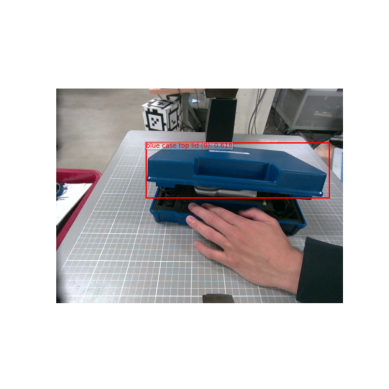

In [4]:
# user_query = "grab the scissors"
# user_query = "grab the screwdriver"
user_query = "open the blue case"
# user_query = "close the blue case"

pcd_wrist, rgbd_wrist = wrist.getPCD()
pcd_wkspc, rgbd_wkspc = wkspc.getPCD()

img_wrist = np.array(rgbd_wrist.color).copy()
img_wkspc = np.array(rgbd_wkspc.color)

grasp_prompt = sf_grasp_selection.grasp_prompt.format(**{"user_query": user_query})
img = Image.fromarray(img_wrist)
image_response = gemini_client.models.generate_content(
    model=GEMINI_MODEL_ID,
    contents=[grasp_prompt, img],
)
# image_response = send_message(gemini_client, model=GEMINI_MODEL_ID, messages=[grasp_prompt, img], model_type="gemini")
grasp_phrase = image_response.text.split("\n")[-1].split(": ")[-1]
print(grasp_phrase)

query = [grasp_phrase]
seg_type = 'box-dbscan'
mask_model = mask_models[seg_type]
pcd_wrist, rgbd_wrist = wrist.getPCD()
pose, pred_image = find_object(rgbd_wrist, query, label_model, mask_model, seg_type, wrist)
np.save("scalingforce/pose.npy", pose)
print(pose)
print(plt.get_backend())
%matplotlib inline
plt.imshow(pred_image)
plt.axis('off')  # Optional: to hide axis values and ticks
plt.show()

In [ ]:
# ROBOT_IP = "192.168.0.4"
# robot = ur5.UR5_Interface(ROBOT_IP, 
#                             freq=6, # 6Hz frequency
#                             record=False,
#                             provide_gripper=True,
#                             provide_ft_sensor=True,)
# robot.start()
# robot.start_ft_sensor()
# G = robot.gripper
# G.reset_parameters()


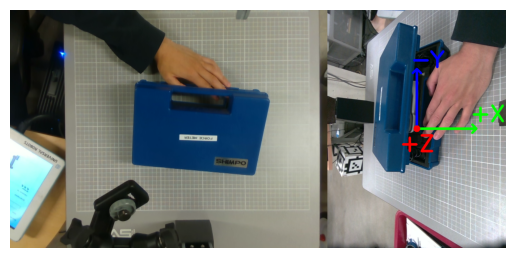

In [5]:
pcd_wkspc2, rgbd_wkspc2 = wkspc.getPCD()
pcd_wrist2, rgbd_wrist2 = wrist.getPCD()
img_wrist2 = np.array(rgbd_wrist2.color)
img_wkspc2 = np.array(rgbd_wkspc2.color)

img_wrist_rotated = cv2.rotate(img_wrist, cv2.ROTATE_90_COUNTERCLOCKWISE)
wrist_img_labeled = label_wrist_image(img_wrist_rotated.copy())
img_wrist2_rotated = cv2.rotate(img_wrist2, cv2.ROTATE_90_COUNTERCLOCKWISE)
wrist_img2_labeled = label_wrist_image(img_wrist2_rotated.copy())
img_wkspc_resized = imutils.resize(img_wkspc, height=img_wrist_rotated.shape[0])
img_wkspc2_resized = imutils.resize(img_wkspc2, height=img_wrist_rotated.shape[0])
# final_img = np.hstack((img_wkspc_resized, wrist_img_labeled))
# final_img = np.hstack((img_wkspc_resized, wrist_img2_labeled))
final_img = np.hstack((img_wkspc2_resized, wrist_img2_labeled))
# final_img = np.hstack((wrist_img_labeled, wrist_img2_labeled, ))

# save img
fn = "axes7_double_wrist.png"
cv2.imwrite(fn, cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(final_img)

In [6]:
# model_type = "gemini"
model_type = "openai"
client, model = None, None
if model_type == "openai":
    client = openai_client
    client_structured = instructor.from_openai(client=client)
    model = OPENAI_MODEL_ID
elif model_type == "gemini":
    client = gemini_client
    client_structured = instructor.from_genai(client=client)
    model = GEMINI_MODEL_ID
img = Image.open('scalingforce/axes7_double_wrist.png').convert("RGB")

# obj = "small servo motor"
prompt_config = {
"obj": grasp_phrase,
"task": user_query
}
# obj = "small servo motor"
# prompt_config = {
# "obj": "small servo motor",
# "task": f"slide the {obj} rapidly up the table for 10 cm"
# }

messages = []
prompt = sf_force_thinker.prompt_motion_thinker.format(**prompt_config)
messages = create_image_message(prompt, img, messages=messages, model_type=model_type)
response = send_message(client, model, messages, model_type=model_type)
motion_plan = force_thinker.process_thinker_response(response)
np.save("scalingforce/motion_plan.npy", motion_plan, allow_pickle=True)
motion_plan

{'position_direction': [1, -1, 0],
 'position_goal': [0.1, 0.05, 0.0],
 'force': [7.5, 5.0, 1.0],
 'grasp_force': 12.5,
 'duration': 3.0}

In [85]:
importlib.reload(ur5)
importlib.reload(gripper)
ROBOT_IP = "192.168.0.4"
robot = ur5.UR5_Interface(ROBOT_IP, 
                            freq=6, # 6Hz frequency
                            record=False,
                            provide_gripper=True,
                            provide_ft_sensor=True,)
robot.start()
robot.start_ft_sensor(poll_rate=100)
G = robot.gripper
G.reset_parameters()
np.save("scalingforce/home.npy", robot.home)
pose = np.load("scalingforce/pose.npy")

Found Dynamixel Port:
/dev/ttyACM0

Succeeded to open the port
Succeeded to change the baudrate


In [8]:
robot.moveL_translation_tooltip(pose, asynch=False)

Tooltip: [0.012 0.006 0.211]
Goal Pos: [-0.178 -0.46   0.297]


In [1]:
import numpy as np
motion_plan = np.load("scalingforce/motion_plan.npy", allow_pickle=True).item()
G.reset_and_close_gripper()
motion_plan

NameError: name 'np' is not defined

In [17]:
camera_dict = {
    wrist: "record/wrist/",
    wkspc: "record/workspace/"
}
camera_dict = {}

In [21]:
goal_delta = np.array(motion_plan['position_goal'])
direction = np.array(motion_plan['position_direction'])
sign = np.where(direction < 0, -1, 1)
force = np.array(motion_plan['force']) * sign
wrench_goal = np.hstack((force, np.zeros(3)))
init_cmd = np.hstack((force / -300, np.zeros(3)))
duration = motion_plan['duration']
# duration = 5
grasp_force = motion_plan['grasp_force']
P = 0.0003 # stiffness gain, default is 0.0005

# robot.force_position_control(wrench=wrench_goal, goal_delta=goal_delta, grasp_force=grasp_force, camera_dict=camera_dict,
#                 init_cmd=init_cmd, tolerance=0.01, duration=duration, p=P, control_type="proportional")

await robot.force_position_control_async(wrench=wrench_goal, goal_delta=goal_delta, grasp_force=grasp_force, camera_dict=camera_dict,
                init_cmd=init_cmd, tolerance=0.01, duration=duration, p=P, control_type="proportional")

robot.ctrl.speedL([0.00, -0.00, 0.00, 0.0, 0.0, 0.0], 0.5, 0.25)


[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!


False

In [19]:
import os
# clear out images in record/wrist/, record/workspace/, record/wkspc
for camera in camera_dict:
    if os.path.exists(camera_dict[camera]):
        for filename in os.listdir(camera_dict[camera]):
            file_path = os.path.join(camera_dict[camera], filename)
            try:
                if os.path.isfile(file_path):
                    os.remove(file_path)
            except Exception as e:
                print(f"Error deleting file {file_path}: {e}")
for camera in camera_dict:
    camera.write_buffer()